In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.09454462/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

# Component 1

Enter measurements for species

In [14]:
logN_dict = {'HI':'14.53, -0.08, +0.08',
            'HeI':'<12.99',
            'CII':'<13.20',
            'CIII':'>13.27, 0.69',
            'CIV':'13.90, -0.03, +0.03',
            'NII':'<13.38',
            'NIV':'13.03,  -0.11, +0.11',
            'NV':'<13.43',
            'OII':'<13.36',
            'OIII':'14.17, -0.05, +0.05',
            'OIV':'14.72, -0.12, +0.12',
            'NeVI':'<13.62',
            'NeVIII':'<13.66',
            'MgII':'<11.36',
            'MgX':'<13.76',
            'AlII':'<11.21',
            'AlIII':'<11.53',
            'SiII':'<12.23',
            'SiIII':'<12.07',
            'SIV':'<12.69',
            'SV':'<12.25',
            'SVI':'<13.41',
            'FeII':'<11.77'}

Try out a solution including sub-solar [C/O], [N/O], [S/O]

In [15]:
logN_HI_test = 14.53
log_hdens_test = -3.6 #-1.7  
log_metals_test = 0.1 #-1.0

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp)

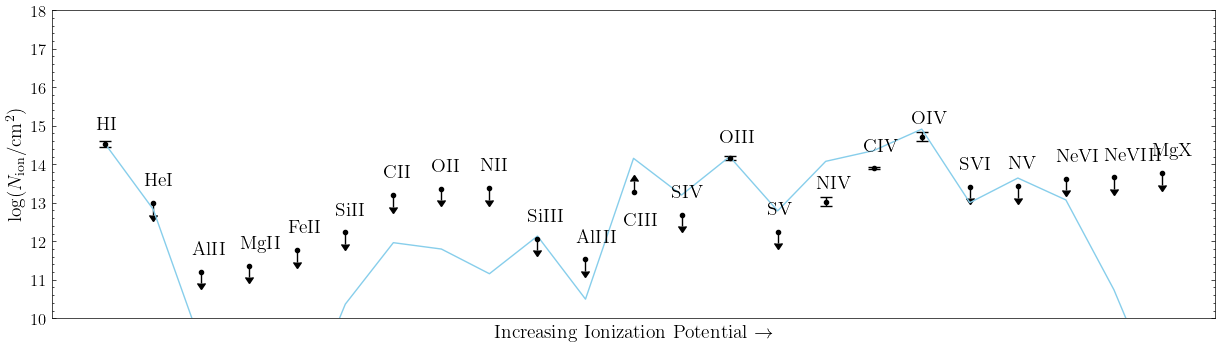

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

# Oxygen only fit

In [18]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original prior function on the full set of parameters
    return log_prior(params_full)

In [19]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [20]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [21]:
ions_oxy = ['OII', 'OIII', 'OIV']

In [22]:
logN_dict_oxy = {ion: logN_dict[ion] for ion in ions_oxy}

In [23]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [24]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy, species_logN_interp)
)

In [25]:
#sampler.run_mcmc(pos, 500, progress=True);

In [26]:
#flat_samples_oxy = pd.DataFrame(sampler.get_chain(discard=100, flat=True), columns=['log_hdens', 'log_metals'])
#flat_samples_oxy.to_csv(savedir+'oxy_solar_flat.csv', index=False)

flat_samples_oxy = pd.read_csv(savedir+'oxy_solar_flat.csv')

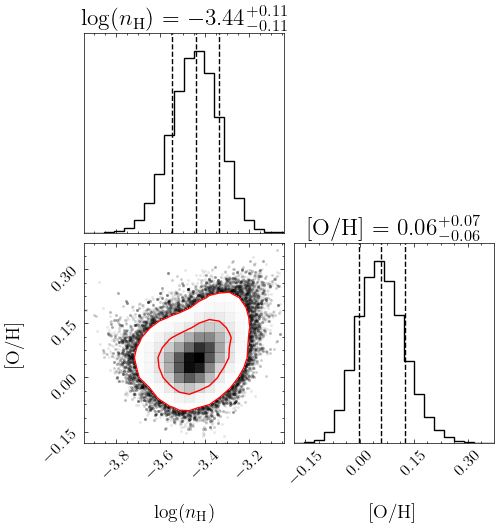

In [27]:
fig = corner.corner(
    flat_samples_oxy.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [28]:
logN_dict = {'HI':'14.53, -0.08, +0.08',
            'HeI':'<12.99',
            'CII':'<13.20',
            'CIII':'>13.27, 0.69',
            'CIV':'13.90, -0.03, +0.03',
            'NII':'<13.38',
            'NIV':'13.03,  -0.11, +0.11',
            'NV':'<13.43',
            'OII':'<13.36',
            'OIII':'14.17, -0.05, +0.05',
            'OIV':'14.72, -0.12, +0.12',
            'NeVI':'<13.62',
            'NeVIII':'<13.66',
            'MgII':'<11.36',
            'MgX':'<13.76',
            'AlII':'<11.21',
            'AlIII':'<11.53',
            'SiII':'<12.23',
            'SiIII':'<12.07',
            'SIV':'<12.69',
            'SV':'<12.25',
            'SVI':'<13.41',
            'FeII':'<11.77'}

In [29]:
sample_indices_oxy = np.random.randint(low=0, high=len(flat_samples_oxy), size=200)

Text(-0.5, 16.5, '$[\\mathrm{O}/\\mathrm{H}] = 0.06_{-0.06}^{+0.07}$')

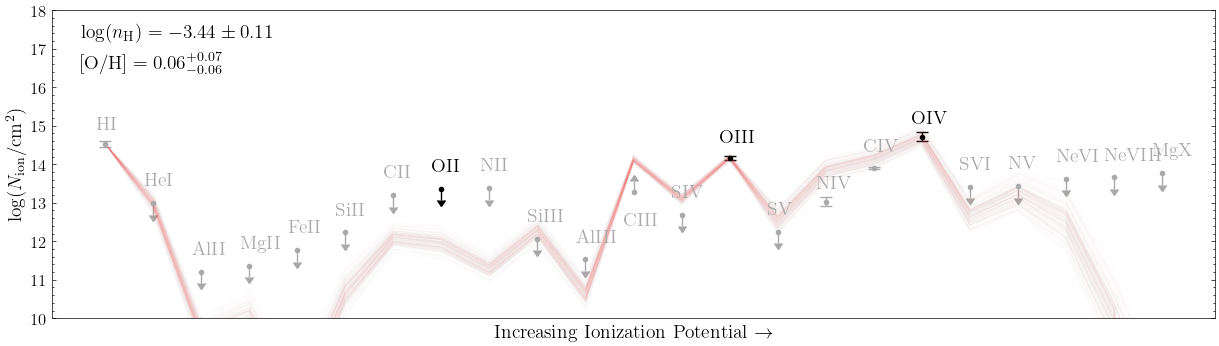

In [30]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'HeI', 'CII', 'CIII',  'CIV', 
                                                         'NII', 'NIV', 'NV',
                                                         'NeVI', 'NeVIII', 'MgII', 'MgX', 'AlII', 'AlIII',
                                                         'SiII', 'SiIII', 'SIV', 'SV',
                                                         'SVI', 'FeII'])

for i in range(len(sample_indices_oxy)):
    
    idx = sample_indices_oxy[i]
    flat_samples_row = flat_samples_oxy.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

ax.text(x=-0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.44 \pm 0.11$')
ax.text(x=-0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = 0.06_{-0.06}^{+0.07}$')

#plt.savefig(savedir+'z=0_72882224_cloudy_oxy.pdf', dpi=300)

# $\alpha$-element only (except S), solar abundance pattern fit

In [31]:
ions_alpha = ['MgII', 'SiII', 'OII', 'SiIII', 'OIII', 'OIV', 'NeVI', 'NeVIII', 'MgX']

In [32]:
logN_dict_alpha = {ion: logN_dict[ion] for ion in ions_alpha}

In [33]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [34]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_alpha, species_logN_interp)
)

In [36]:
#sampler.run_mcmc(pos, 500, progress=True);

In [37]:
#flat_samples_alpha = pd.DataFrame(sampler.get_chain(discard=100, flat=True), columns=['log_hdens', 'log_metals'])
#flat_samples_alpha.to_csv(savedir+'alpha_solar_flat.csv', index=False)

flat_samples_alpha = pd.read_csv(savedir+'alpha_solar_flat.csv')

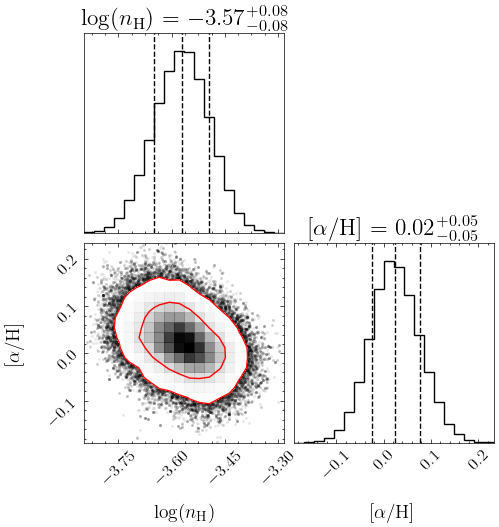

In [38]:
fig = corner.corner(
    flat_samples_alpha.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\alpha/\mathrm{H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [39]:
logN_dict = {'HI':'14.53, -0.08, +0.08',
            'HeI':'<12.99',
            'CII':'<13.20',
            'CIII':'>13.27, 0.69',
            'CIV':'13.90, -0.03, +0.03',
            'NII':'<13.38',
            'NIV':'13.03,  -0.11, +0.11',
            'NV':'<13.43',
            'OII':'<13.36',
            'OIII':'14.17, -0.05, +0.05',
            'OIV':'14.72, -0.12, +0.12',
            'NeVI':'<13.62',
            'NeVIII':'<13.66',
            'MgII':'<11.36',
            'MgX':'<13.76',
            'AlII':'<11.21',
            'AlIII':'<11.53',
            'SiII':'<12.23',
            'SiIII':'<12.07',
            'SIV':'<12.69',
            'SV':'<12.25',
            'SVI':'<13.41',
            'FeII':'<11.77'}

In [40]:
sample_indices_alpha = np.random.randint(low=0, high=len(flat_samples_alpha), size=200)

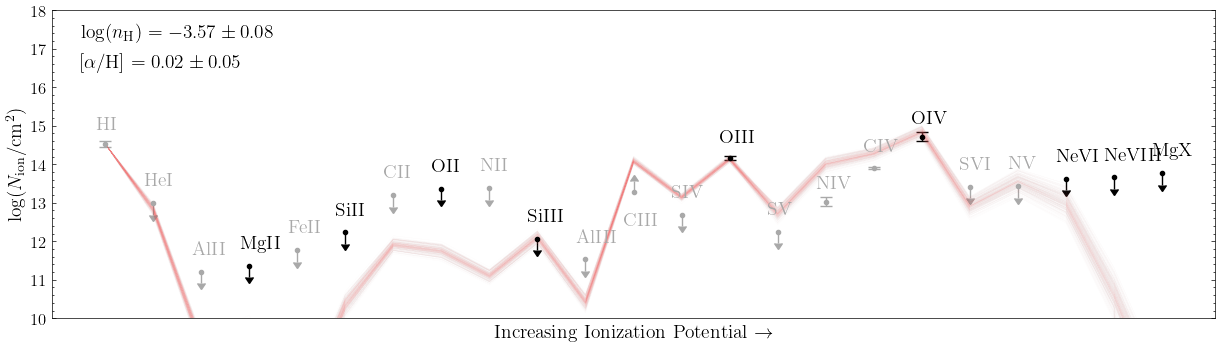

In [41]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'HeI', 'CII', 'CIII',  'CIV', 
                                                         'NII', 'NIV', 'NV',
                                                         'AlII', 'AlIII',
                                                         'SIV', 'SV',
                                                         'SVI', 'FeII'])

for i in range(len(sample_indices_alpha)):
    
    idx = sample_indices_alpha[i]
    flat_samples_row = flat_samples_alpha.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

ax.text(x=-0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.57 \pm 0.08$')
ax.text(x=-0.5, y=16.5, s=r'$[\mathrm{\alpha}/\mathrm{H}] = 0.02 \pm 0.05$')

plt.savefig(savedir+'z=1_09454462_cloudy_alpha.pdf', dpi=300)